# ChestXRay Diagnosis Tool — Data Preprocessing & Model Training

**Module A** of the diagnostic pipeline.  
This notebook handles the complete workflow from raw data to a trained DenseNet-121 model.

| Disease | NIH CSV Label |
|---|---|
| Cardiomegaly (Enlarged Heart) | `Cardiomegaly` |
| Pleural Effusion (Fluid in Lungs) | `Effusion` |
| Pneumothorax (Collapsed Lung) | `Pneumothorax` |
| Healthy Baseline | `No Finding` |

---
### Workflow
**Part 1 — Data Preprocessing:** Download → Filter → Move → Label  
**Part 2 — Model Training:** Dataset → Splits → DenseNet-121 → Train → Evaluate → Save

---
# Part 1 — Data Preprocessing

## Step 1 — Kaggle Setup & Download the CSV

In [ ]:
!pip install -q kaggle

# Upload your kaggle.json when prompted
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download JUST the CSV first (tiny ~1 MB)
!kaggle datasets download -d nih-chest-xrays/data -f Data_Entry_2017.csv
!unzip -o Data_Entry_2017.csv.zip

## Step 2 — Filter the CSV for our 3 target diseases

**Important:** The NIH CSV uses `"Effusion"` — NOT `"Pleural_Effusion"`.  
We use **set-based matching** (not regex) to avoid false positives.

In [ ]:
import pandas as pd

df = pd.read_csv('Data_Entry_2017.csv')
print(f"Total images in dataset: {len(df):,}")

# --- Target diseases (EXACT label strings from the NIH CSV) ---
TARGET_DISEASES = ['Cardiomegaly', 'Effusion', 'Pneumothorax']
NO_FINDING = 'No Finding'

# Parse pipe-separated labels into a Python set per row
# e.g. "Cardiomegaly|Effusion" -> {'Cardiomegaly', 'Effusion'}
df['labels_set'] = df['Finding Labels'].apply(lambda s: set(str(s).split('|')))

# Keep rows with at least one target disease OR pure "No Finding"
targets = set(TARGET_DISEASES)
mask = df['labels_set'].apply(
    lambda s: bool(s & targets) or s == {NO_FINDING}
)
filtered_df = df[mask].copy()

# --- Multi-hot encoded label columns ---
for disease in TARGET_DISEASES:
    filtered_df[f'label_{disease}'] = filtered_df['labels_set'].apply(
        lambda s, d=disease: int(d in s)
    )

filtered_df.drop(columns=['labels_set'], inplace=True)

# --- Stats ---
images_to_keep = set(filtered_df['Image Index'].tolist())
print(f"\nFiltered to {len(filtered_df):,} images.\n")
print("Label distribution:")
for disease in TARGET_DISEASES:
    col = f'label_{disease}'
    pos = filtered_df[col].sum()
    print(f"  {disease:<20} {pos:>6,} positives  ({pos/len(filtered_df)*100:.1f}%)")

no_finding = (filtered_df[[f'label_{d}' for d in TARGET_DISEASES]].sum(axis=1) == 0).sum()
print(f"  {'No Finding':<20} {no_finding:>6,} images    ({no_finding/len(filtered_df)*100:.1f}%)")

## Step 3 — Download & extract the full image dataset

Downloads ~45 GB from Kaggle to Colab (cloud-to-cloud, ~1-2 min).  
Extracts all 112K images into 12 sub-folders.

In [ ]:
!kaggle datasets download -d nih-chest-xrays/data
!unzip -q data.zip -d all_images
!ls all_images/

## Step 4 — Move only our filtered images into a clean folder

Uses `shutil.move` instead of copy — faster and frees disk space as it goes.

In [ ]:
import os
import shutil
from pathlib import Path

SRC_ROOT = Path('all_images')
DST_DIR = Path('my_custom_dataset')
DST_DIR.mkdir(exist_ok=True)

# Build a lookup: filename -> full path (scans all 12 sub-folders)
print('Building image index across all sub-folders...')
image_index = {}
for png in SRC_ROOT.rglob('*.png'):
    image_index[png.name] = png
print(f'Found {len(image_index):,} total .png files.\n')

# Move only the filtered images
moved = 0
missing = []
for i, filename in enumerate(images_to_keep):
    src = image_index.get(filename)
    if src:
        shutil.move(str(src), DST_DIR / filename)
        moved += 1
    else:
        missing.append(filename)

    if (i + 1) % 5000 == 0:
        print(f'  Moved {moved:,} / {i+1:,} ...')

print(f'\nDone! Moved {moved:,} images to {DST_DIR}/')
if missing:
    print(f'Warning: {len(missing)} images not found.')

## Step 5 — Save the filtered CSV & clean up

Saves `labels.csv` with multi-hot columns alongside the images.  
Deletes `all_images/` and `data.zip` to free disk space for training.

In [ ]:
# Save the labelled CSV
csv_out = '/content/my_custom_dataset/labels.csv'
filtered_df.to_csv(csv_out, index=False)
print(f'Saved filtered CSV -> {csv_out}')
print(f'Columns: {list(filtered_df.columns)}\n')

# Free up disk space — delete the leftover originals
!rm -rf all_images data.zip Data_Entry_2017.csv.zip
print('Cleaned up leftover files to free disk space.')

# Show what we have
!du -sh my_custom_dataset/
filtered_df.head()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import shutil

# Define source and destination paths
source_path = '/content/my_custom_dataset/'
destination_path = '/content/drive/MyDrive/my_custom_dataset'

print(f'Moving {source_path} to {destination_path}...')
shutil.move(source_path, destination_path)
print('Move complete!')

---
# Part 2 — Model Training

Fine-tuning a pre-trained **DenseNet-121** for 3-class multi-label classification  
using `BCEWithLogitsLoss`.

> **Make sure your Colab runtime has a GPU enabled:**  
> Runtime → Change runtime type → T4 GPU

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Mounted at /content/drive


## Step 6 — Imports & Configuration

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from sklearn.metrics import roc_auc_score

# ---- Configuration ----
DATASET_DIR   = '/content/drive/MyDrive/my_custom_dataset'
CSV_PATH      = '/content/drive/MyDrive/my_custom_dataset/labels.csv'
TARGET_DISEASES = ['Cardiomegaly', 'Effusion', 'Pneumothorax']
NUM_CLASSES   = len(TARGET_DISEASES)

IMAGE_SIZE    = 224
BATCH_SIZE    = 32
NUM_EPOCHS    = 15
LEARNING_RATE = 1e-4
NUM_WORKERS   = 2
RANDOM_SEED   = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## Step 7 — PyTorch Dataset Class

Loads each X-ray image, converts grayscale to RGB (DenseNet expects 3 channels),  
and returns a `[3, 224, 224]` image tensor + a `[3]` multi-hot label tensor.

In [ ]:
class ChestXrayDataset(Dataset):

    """
    PyTorch Dataset for the filtered NIH Chest X-ray images.

    Returns:
        image:  [3, 224, 224] float32 tensor (ImageNet-normalised)
        label:  [3] float32 tensor (multi-hot: Cardiomegaly, Effusion, Pneumothorax)
    """

    def __init__(self, dataframe, image_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.label_columns = [f'label_{d}' for d in TARGET_DISEASES]

        # Only keep rows where the file ACTUALLY exists right now
        valid = []
        for _, row in dataframe.iterrows():
            if (self.image_dir / row['Image Index']).exists():
                valid.append(row)

        self.dataframe = pd.DataFrame(valid).reset_index(drop=True)
        print(f'  Verified {len(self.dataframe)} / {len(dataframe)} images exist.')

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = self.image_dir / row['Image Index']
        image = Image.open(img_path)

        if image.mode != 'RGB':
            image = image.convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            row[self.label_columns].values.astype(np.float32),
            dtype=torch.float32
        )

        return image, label


## Step 8 — Image Transforms

**Training:** Augmentation (flip, rotation, small shift) + ImageNet normalisation.  
**Validation/Test:** Only resize + normalise (no augmentation — we want consistent evaluation).

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    # ImageNet stats — required because DenseNet-121 was pre-trained on ImageNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

In [ ]:
import os
import pandas as pd

# 1. Load the CSV first!
full_df = pd.read_csv(CSV_PATH)

# 2. Get the set of images that actually exist
existing_images = set(f for f in os.listdir(DATASET_DIR) if f.endswith('.png'))
print(f'Images on Drive: {len(existing_images):,}')

# 3. Filter the DataFrame to only include images we actually have
before = len(full_df)
full_df = full_df[full_df['Image Index'].isin(existing_images)].reset_index(drop=True)
print(f'CSV rows: {before:,} -> {len(full_df):,} (dropped {before - len(full_df):,} missing images)')

Images on Drive: 57,876
CSV rows: 79,675 -> 57,867 (dropped 21,808 missing images)


## Step 9 — Patient-Aware Train / Val / Test Split

We split by **Patient ID** so no patient's X-rays leak across splits.  
This prevents the model from memorising patient-specific features.

In [ ]:
import os
import pandas as pd
import numpy as np

# 1. Load the CSV
full_df = pd.read_csv(CSV_PATH)

# 2. Get the set of images that actually exist on your Drive
existing_images = set(f for f in os.listdir(DATASET_DIR) if f.endswith('.png'))
print(f'Images found on Drive: {len(existing_images):,}')

# 3. Filter the DataFrame to only include images we actually have
before = len(full_df)
full_df = full_df[full_df['Image Index'].isin(existing_images)].reset_index(drop=True)
print(f'CSV rows: {before:,} -> {len(full_df):,} (dropped {before - len(full_df):,} missing images)')

# --- NEW: Subsample to 10k images for fast training ---
if len(full_df) > 10000:
    full_df = full_df.sample(n=10000, random_state=RANDOM_SEED).reset_index(drop=True)
    print(f'\nSubsampled dataset to {len(full_df):,} images.\n')

# 4. Get unique patients and shuffle
patient_ids = full_df['Patient ID'].unique()
np.random.seed(RANDOM_SEED)
np.random.shuffle(patient_ids)

# 5. 70% train / 15% val / 15% test (by patient count)
n = len(patient_ids)
train_end = int(n * 0.70)
val_end   = train_end + int(n * 0.15)

train_patients = set(patient_ids[:train_end])
val_patients   = set(patient_ids[train_end:val_end])
test_patients  = set(patient_ids[val_end:])

train_df = full_df[full_df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df   = full_df[full_df['Patient ID'].isin(val_patients)].reset_index(drop=True)
test_df  = full_df[full_df['Patient ID'].isin(test_patients)].reset_index(drop=True)

print(f'Train : {len(train_df):>7,} images  ({len(train_patients):,} patients)')
print(f'Val   : {len(val_df):>7,} images  ({len(val_patients):,} patients)')
print(f'Test  : {len(test_df):>7,} images  ({len(test_patients):,} patients)')


Images found on Drive: 57,876
CSV rows: 79,675 -> 57,867 (dropped 21,808 missing images)

Subsampled dataset to 10,000 images.

Train :   6,923 images  (4,737 patients)
Val   :   1,578 images  (1,015 patients)
Test  :   1,499 images  (1,016 patients)


## Step 10 — DataLoaders with Weighted Sampling

The dataset is imbalanced ("No Finding" dominates). We use a **WeightedRandomSampler**  
that up-samples minority disease classes so the model sees a balanced distribution each epoch.

In [ ]:
# --- Create Datasets ---
train_dataset = ChestXrayDataset(train_df, DATASET_DIR, transform=train_transforms)
val_dataset   = ChestXrayDataset(val_df,   DATASET_DIR, transform=eval_transforms)
test_dataset  = ChestXrayDataset(test_df,  DATASET_DIR, transform=eval_transforms)

# --- Weighted Sampler — use the VERIFIED dataframe from the dataset ---
label_cols = [f'label_{d}' for d in TARGET_DISEASES]
labels = train_dataset.dataframe[label_cols].values  # ← use train_dataset.dataframe, not train_df

pos_counts = labels.sum(axis=0)
class_weights = len(labels) / (pos_counts + 1e-6)

sample_weights = (labels * class_weights).sum(axis=1)
sample_weights[labels.sum(axis=1) == 0] = 1.0

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float64),
    num_samples=len(train_dataset),   # ← match the actual dataset size
    replacement=True
)

# --- Build DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader):,}')
print(f'Val batches   : {len(val_loader):,}')
print(f'Test batches  : {len(test_loader):,}')


  Verified 6923 / 6923 images exist.
  Verified 1578 / 1578 images exist.
  Verified 1499 / 1499 images exist.
Train batches : 216
Val batches   : 50
Test batches  : 47


## Step 11 — Sanity Check

Grab one batch and verify shapes before training.

In [ ]:
images, labels = next(iter(train_loader))
print(f'images.shape = {images.shape}')   # [32, 3, 224, 224]
print(f'images.dtype = {images.dtype}')    # float32
print(f'labels.shape = {labels.shape}')    # [32, 3]
print(f'labels.dtype = {labels.dtype}')    # float32
print(f'\nFirst 5 labels:\n{labels[:5]}')

images.shape = torch.Size([32, 3, 224, 224])
images.dtype = torch.float32
labels.shape = torch.Size([32, 3])
labels.dtype = torch.float32

First 5 labels:
tensor([[0., 0., 0.],
        [0., 0., 1.],
        [1., 1., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


## Step 12 — Build the DenseNet-121 Model

We load a pre-trained DenseNet-121 and **replace its final classifier layer**  
to output 3 raw logits (one per disease). No sigmoid here —  
`BCEWithLogitsLoss` applies sigmoid internally for numerical stability.

In [ ]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last dense block + classifier (fine-tune only the top)
for param in model.features.denseblock4.parameters():
    param.requires_grad = True
for param in model.features.norm5.parameters():
    param.requires_grad = True

# Replace classifier
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, NUM_CLASSES)  # new layer, requires_grad=True by default

model = model.to(DEVICE)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total:,}')
print(f'Trainable parameters: {trainable:,} ({trainable/total*100:.1f}%)')


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 109MB/s]


Total parameters:     6,956,931
Trainable parameters: 2,163,203 (31.1%)


## Step 13 — Loss Function, Optimizer & Scheduler

- **BCEWithLogitsLoss:** Combines sigmoid + binary cross-entropy in one numerically stable step.  
  Perfect for multi-label (each disease is an independent binary prediction).  
- **Adam optimizer** with a low learning rate (we're fine-tuning, not training from scratch).  
- **ReduceLROnPlateau:** Drops the learning rate when validation loss stops improving.

In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print('Loss:      BCEWithLogitsLoss')
print(f'Optimizer: Adam (lr={LEARNING_RATE})')
print('Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)')

Loss:      BCEWithLogitsLoss
Optimizer: Adam (lr=0.0001)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)


## Step 14 — Training Loop

For each epoch:
1. **Train** — forward pass, compute loss, backprop, update weights.  
2. **Validate** — forward pass only, compute loss + AUC-ROC per disease.  
3. **Checkpoint** — save the model if validation loss improves (early stopping patience = 5).

In [ ]:
# Create a GradScaler for mixed precision
scaler = torch.amp.GradScaler('cuda')

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass in float16 — faster math, less memory
        with torch.amp.autocast('cuda'):
            logits = model(images)
            loss = criterion(logits, labels)

        # Backward pass with scaled gradients
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)



def validate(model, loader, criterion, device):
    """Run validation. Returns average loss + per-class AUC-ROC."""
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)

            # Convert logits to probabilities for AUC calculation
            probs = torch.sigmoid(logits)
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    # Compute per-class AUC-ROC
    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    aucs = {}
    for i, disease in enumerate(TARGET_DISEASES):
        try:
            aucs[disease] = roc_auc_score(all_labels[:, i], all_probs[:, i])
        except ValueError:
            aucs[disease] = 0.0  # If only one class present in batch

    return epoch_loss, aucs

In [ ]:
# --- Training ---
best_val_loss = float('inf')
patience_counter = 0
EARLY_STOP_PATIENCE = 5
history = {'train_loss': [], 'val_loss': [], 'val_aucs': []}

print(f'Starting training for {NUM_EPOCHS} epochs...\n')
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Val Loss":>10} | '
      f'{"Cardiomeg.":>10} | {"Effusion":>10} | {"Pneumo.":>10} | {"Mean AUC":>10}')
print('-' * 85)

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # Validate
    val_loss, val_aucs = validate(model, val_loader, criterion, DEVICE)

    # Step the scheduler
    scheduler.step(val_loss)

    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_aucs'].append(val_aucs)

    mean_auc = np.mean(list(val_aucs.values()))

    # Print epoch results
    print(f'{epoch:>5} | {train_loss:>10.4f} | {val_loss:>10.4f} | '
          f'{val_aucs["Cardiomegaly"]:>10.4f} | {val_aucs["Effusion"]:>10.4f} | '
          f'{val_aucs["Pneumothorax"]:>10.4f} | {mean_auc:>10.4f}')

    # Checkpoint — save if validation loss improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_aucs': val_aucs,
        }, 'best_model.pth')
        print(f'      -> Saved best model (val_loss={val_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {EARLY_STOP_PATIENCE} epochs).')
            break

print(f'\nTraining complete! Best validation loss: {best_val_loss:.4f}')

Starting training for 15 epochs...

Epoch | Train Loss |   Val Loss | Cardiomeg. |   Effusion |    Pneumo. |   Mean AUC
-------------------------------------------------------------------------------------
    1 |     0.5353 |     0.3711 |     0.7764 |     0.7991 |     0.7502 |     0.7752
      -> Saved best model (val_loss=0.3711)
    2 |     0.4113 |     0.3529 |     0.8087 |     0.8044 |     0.7059 |     0.7730
      -> Saved best model (val_loss=0.3529)
    3 |     0.3450 |     0.3299 |     0.8250 |     0.7996 |     0.7499 |     0.7915
      -> Saved best model (val_loss=0.3299)
    4 |     0.2905 |     0.3411 |     0.8123 |     0.7938 |     0.7553 |     0.7871
    5 |     0.2525 |     0.3565 |     0.8005 |     0.7800 |     0.7366 |     0.7724
    6 |     0.2188 |     0.3560 |     0.8120 |     0.7698 |     0.7518 |     0.7779
    7 |     0.1972 |     0.3387 |     0.8321 |     0.7622 |     0.7334 |     0.7759
    8 |     0.1778 |     0.3429 |     0.8185 |     0.7799 |     0.7549 |  

## Step 15 — Plot Training Curves

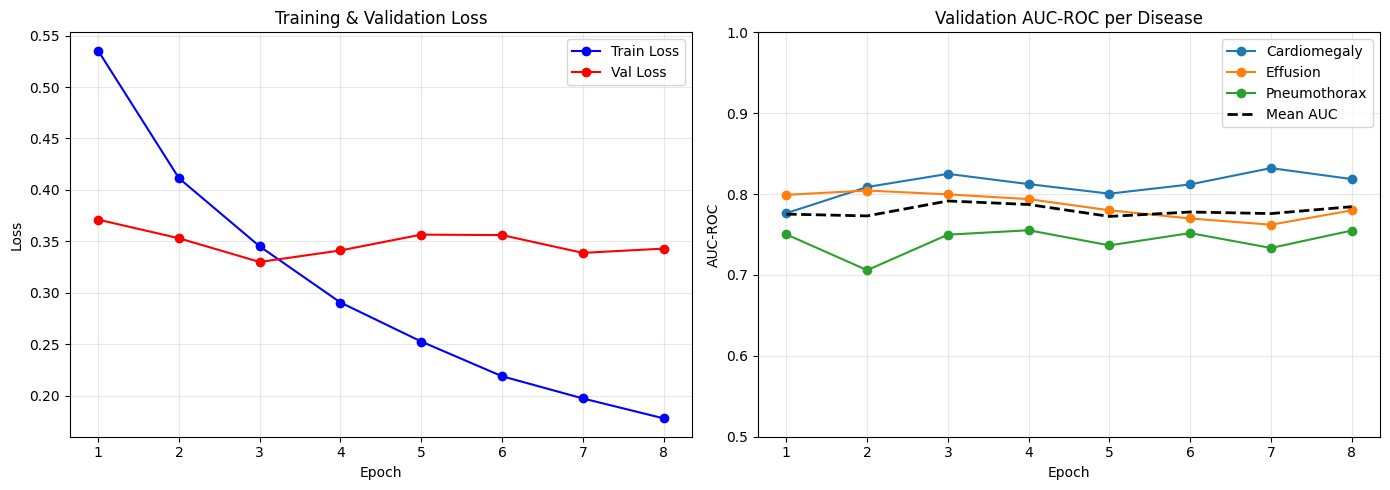

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curves ---
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- AUC curves ---
for disease in TARGET_DISEASES:
    auc_values = [epoch_aucs[disease] for epoch_aucs in history['val_aucs']]
    ax2.plot(epochs_range, auc_values, '-o', label=disease)

mean_aucs = [np.mean(list(a.values())) for a in history['val_aucs']]
ax2.plot(epochs_range, mean_aucs, 'k--', linewidth=2, label='Mean AUC')

ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC-ROC')
ax2.set_title('Validation AUC-ROC per Disease')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.show()

## Step 16 — Evaluate on Test Set

Load the best checkpoint and run final evaluation on the held-out test set.

In [ ]:
# Load best model
checkpoint = torch.load('best_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Loaded best model from epoch {checkpoint["epoch"]}\n')

# Evaluate on test set
test_loss, test_aucs = validate(model, test_loader, criterion, DEVICE)

print('=' * 50)
print('  FINAL TEST SET RESULTS')
print('=' * 50)
print(f'  Test Loss: {test_loss:.4f}\n')
print(f'  Per-disease AUC-ROC:')
for disease in TARGET_DISEASES:
    print(f'    {disease:<20} {test_aucs[disease]:.4f}')
print(f'\n  Mean AUC-ROC: {np.mean(list(test_aucs.values())):.4f}')
print('=' * 50)

Loaded best model from epoch 3

  FINAL TEST SET RESULTS
  Test Loss: 0.3264

  Per-disease AUC-ROC:
    Cardiomegaly         0.7552
    Effusion             0.8174
    Pneumothorax         0.7478

  Mean AUC-ROC: 0.7735


## Step 17 — Download the trained model

Download `best_model.pth` to your laptop for use in Module B (Grad-CAM) and the backend API.

In [ ]:
import os
size_mb = os.path.getsize('best_model.pth') / (1024**2)
print(f'Model size: {size_mb:.1f} MB\n')

from google.colab import files
files.download('best_model.pth')

Model size: 43.7 MB



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>